# Fine-tuning of flan-t5-base for extractive QA (AdversarialQA)

This notebook fine-tunes `flan-t5-base` on the task, selects the learning rate on validation F1, evaluates the fine-tuned model, and publishes the resulting checkpoint to the Hugging Face Hub.

## Experimental constraints
- **Splits**: the existing splits from `load_processed()` are reused (`train` 27k, `val` 3k); the `test` split is reserved for final evaluation. No re-splitting, so the pre/post fine-tuning comparison stays valid.
- **No re-tokenization**: training uses the dataset's `input_ids` / `attention_mask` / `labels` directly, with the same prompt template as the baseline.
- **Selection metric**: token-level F1 on `val`, computed with the same greedy generation as `evaluate.py` (`max_new_tokens=48`). Scores are on a 0–1 scale.

## Method
- **Full fine-tuning** of all parameters. `flan-t5-base` (~250M) fits a Colab T4 (16 GB) with gradient checkpointing, so no layer freezing is required (`FREEZE_ENCODER` is kept as a fallback).
- Full fine-tuning yields a single checkpoint that is loaded exactly like the baseline, with no adapter-merging step.
- **FP32 on the T4**: the T4 has no native BF16, and FP16 is unstable for T5. A single training run is performed; quantization is applied afterwards to this checkpoint.

In [1]:
# --- Colab setup: clone repo + install pinned deps ---
!git clone https://github.com/Julianlls/DeepLearning.git
%cd DeepLearning
# pin to the project versions used across the repo
!pip install -q "transformers==5.17.0" "datasets==5.0.1" "accelerate==1.15.0"

Cloning into 'DeepLearning'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 116 (delta 54), reused 92 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 257.44 KiB | 6.44 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/DeepLearning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.9 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd()))   # make src importable (cwd == repo root after %cd)

import numpy as np
import inspect
import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Trainer, TrainingArguments,
    set_seed,
)

from src.config import MODEL_BASE, MAX_GEN_TOKENS, EVAL_BATCH_SIZE, SEED
from src.preprocessing import load_processed
from src.evaluate import evaluate_model

print("transformers version:", __import__("transformers").__version__)

set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
assert device == "cuda", "Use a GPU runtime (Colab T4). Training on CPU is not practical."

tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)

# First call downloads + rebuilds the SAME splits (seed 42) and tokenizes; then cached on disk.
ds = load_processed()
print(ds)

transformers version: 5.17.0
device: cuda


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/27000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'metadata', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 27000
    })
    val: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'metadata', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'metadata', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
})


## Training data

Only the model columns (`input_ids`, `attention_mask`, `labels`) are kept for training. The full `ds["val"]` (which retains `answers`) is used for the final evaluation via `evaluate_model()`.

In [3]:
KEEP = ["input_ids", "attention_mask", "labels"]

def keep_model_cols(split):
    drop = [c for c in split.column_names if c not in KEEP]
    return split.remove_columns(drop)

train_tok = keep_model_cols(ds["train"])   # 27k, for training
val_tok   = keep_model_cols(ds["val"])     # 3k,  for in-loop selection

# Dynamic padding; labels padded with -100 so pad tokens are ignored by the loss.
data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=None, label_pad_token_id=-100, padding=True
)

print(train_tok, val_tok, sep="\n")

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 27000
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 3000
})


## Learning-rate search

The learning rate is selected with a short probe: one epoch on a train subset, scored on a validation subset via `evaluate_model()` (greedy, `max_new_tokens=48`), consistent with the final evaluation.

`TrainingArguments` differ across `transformers` releases, so `make_args()` keeps only the arguments accepted by the installed version. Training uses the standard `Trainer`; all generation goes through `evaluate_model()`.

In [4]:
# ---- search knobs (tune for your runtime budget) ----
SEARCH_TRAIN_N = 8000     # train subset used only to rank LRs
SEARCH_VAL_N   = 1000     # val subset used only to rank LRs
SEARCH_EPOCHS  = 1
LR_GRID        = [5e-5, 1e-4, 3e-4]

TRAIN_BS = 8
GA_STEPS = 2              # effective batch = TRAIN_BS * GA_STEPS = 16

search_train    = train_tok.select(range(SEARCH_TRAIN_N))     # only model cols, for training
search_val_eval = ds["val"].select(range(SEARCH_VAL_N))       # full rows (has 'answers'), for evaluate_model

FREEZE_ENCODER = False   # fallback if GPU memory is insufficient: freezes the encoder (decoder-only fine-tuning)

def build_model():
    m = AutoModelForSeq2SeqLM.from_pretrained(MODEL_BASE)
    m.gradient_checkpointing_enable()   # fit full FT on a T4
    m.config.use_cache = False          # required with gradient checkpointing
    if FREEZE_ENCODER:
        for p in m.encoder.parameters():
            p.requires_grad = False
        print("encoder frozen -> training decoder + lm_head only")
    return m

# only pass the kwargs accepted by the installed transformers version
_ALLOWED_TARGS = set(inspect.signature(TrainingArguments.__init__).parameters)

def make_args(output_dir, lr, epochs):
    desired = dict(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=TRAIN_BS,
        gradient_accumulation_steps=GA_STEPS,
        num_train_epochs=epochs,
        weight_decay=0.0,
        warmup_ratio=0.05,
        logging_steps=100,
        save_strategy="no",          # we save the final model manually
        report_to="none",
        seed=SEED,
        # T4: FP32. (fp16 breaks T5; bf16 not native on Turing.) Flip bf16=True only on A100.
        fp16=False,
        bf16=False,
    )
    kept    = {k: v for k, v in desired.items() if k in _ALLOWED_TARGS}
    dropped = [k for k in desired if k not in _ALLOWED_TARGS]
    if dropped:
        print("skipped unsupported TrainingArguments for this version:", dropped)
    return TrainingArguments(**kept)

def val_f1(model, eval_ds):
    "F1 on a val slice via the repo's evaluate_model (greedy, max_new_tokens=48)."
    model.config.use_cache = True                 # faster generation
    row, _ = evaluate_model(model, tokenizer, eval_ds,
                            model_name="flan-t5-base", state="tmp", precision_mode="fp32")
    model.config.use_cache = False
    return row["f1"], row

In [5]:
search_results = []

for lr in LR_GRID:
    set_seed(SEED)
    model = build_model()
    args = make_args(f"search_lr{lr}", lr, SEARCH_EPOCHS)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=search_train,
        data_collator=data_collator,
    )
    trainer.train()
    f1, _ = val_f1(model, search_val_eval)
    print(f"lr={lr:.0e} -> val({SEARCH_VAL_N}) F1 = {f1:.4f}")
    search_results.append({"lr": lr, "f1": f1})

    del trainer, model
    torch.cuda.empty_cache()

best_lr = max(search_results, key=lambda r: r["f1"])["lr"]
print("\nsearch results:", search_results)
print("best LR:", best_lr)

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


note: this transformers version doesn't accept ['warmup_ratio'] -> skipped


Step,Training Loss
100,1.313679
200,1.291060
300,1.279521
400,1.222358
500,1.170368


generating:   0%|          | 0/125 [00:00<?, ?it/s]

lr=3e-04 -> val(1000) F1 = 0.6551

search results: [{'lr': 5e-05, 'f1': 0.72329}, {'lr': 0.0001, 'f1': 0.72146}, {'lr': 0.0003, 'f1': 0.65511}]
best LR: 5e-05


## Final training

The model is trained on the full 27k train set with the selected learning rate, then saved. If the validation F1 drops with more epochs, reduce `FINAL_EPOCHS`.

In [6]:
FINAL_EPOCHS = 3

set_seed(SEED)
model = build_model()
args = make_args("ckpt_final", best_lr, FINAL_EPOCHS)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    data_collator=data_collator,
)
trainer.train()

# save the fine-tuned checkpoint locally (models/ is gitignored)
SAVE_DIR = "models/flan-t5-base-ft"
model.config.use_cache = True
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("saved ->", SAVE_DIR)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


note: this transformers version doesn't accept ['warmup_ratio'] -> skipped


Step,Training Loss
100,1.114185
200,1.040139
300,1.084049
400,1.064982
500,1.046786
600,1.074460
700,1.097397
800,1.067557
900,1.030092
1000,1.079667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved -> models/flan-t5-base-ft


## Evaluation on the validation set

The saved checkpoint is scored with `evaluate_model()` on the full `ds["val"]`, using the same generation configuration and references as the baseline evaluation, so the numbers are directly comparable.

In [7]:
ft_model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_DIR).to(device)
ft_model.config.use_cache = True   # re-enable cache for fast generation

row, preds = evaluate_model(
    ft_model, tokenizer, ds["val"],
    model_name="flan-t5-base",   # kept as in the baseline; the state field distinguishes raw vs fine-tuned
    state="finetuned",
    precision_mode="fp32",
)
print("VAL (authoritative):")
for k, v in row.items():
    print(f"  {k:16} {v}")

# quick before/after gap check on a few examples
for i in range(8):
    print(f"\nQ: {ds['val'][i]['question']}")
    print(f"  target: {ds['val'][i]['answers']['text'][0]!r}")
    print(f"  pred:   {preds[i]!r}")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generating:   0%|          | 0/375 [00:00<?, ?it/s]

VAL (authoritative):
  model_name       flan-t5-base
  state            finetuned
  precision_mode   fp32
  exact_match      0.61
  precision        0.73486
  recall           0.73548
  f1               0.71111
  n_examples       3000

Q: Which event happened first, the fall of Shanghai or the capturing of Nanking?
  target: 'Shanghai fell'
  pred:   'Shanghai fell'

Q: In general, how can one stay healthy longer?
  target: 'recognize the different characteristics of various diseases'
  pred:   'recognize the different characteristics of various diseases'

Q: Michael C. Graham thinks the things described by some theorists as discrete and consistent response actually are?
  target: 'on a continuum'
  pred:   'on a continuum of intensity'

Q: What is the single Asian country that belongs to the informal body of world leaders?
  target: 'Japan'
  pred:   'Japan'

Q: What did Adrian Kingsley-Hughes describe to be the reasons for his criticisms?
  target: 'due to its inconsistent design'
  

## Evaluation on the test set

Final performance of the fine-tuned model on the held-out `test` split (FP32), for comparison with the raw baseline.

In [ ]:
# Final performance of the fine-tuned model on the held-out test split (FP32)
test_row, test_preds = evaluate_model(
    ft_model, tokenizer, ds["test"],
    model_name="flan-t5-base", state="finetuned", precision_mode="fp32",
)
print("TEST (fine-tuned, FP32):")
for k, v in test_row.items():
    print(f"  {k:16} {v}")

TEST (fine-tuned, FP32):
  model_name       flan-t5-base
  state            finetuned
  precision_mode   fp32
  exact_match      0.444
  precision        0.56737
  recall           0.58402
  f1               0.55009
  n_examples       3000


## Figures

Two figures for the report: the learning-rate search, and a comparison of the raw vs fine-tuned base on the same `val` split (EM and F1). The second requires one evaluation of the raw base on `val`; it also shows whether the EM–F1 gap changes after fine-tuning.

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generating:   0%|          | 0/375 [00:00<?, ?it/s]

raw val: {'model_name': 'flan-t5-base', 'state': 'raw', 'precision_mode': 'fp32', 'exact_match': 0.62433, 'precision': 0.74844, 'recall': 0.73434, 'f1': 0.71764, 'n_examples': 3000}
ft  val: {'model_name': 'flan-t5-base', 'state': 'finetuned', 'precision_mode': 'fp32', 'exact_match': 0.61, 'precision': 0.73486, 'recall': 0.73548, 'f1': 0.71111, 'n_examples': 3000}
EM-F1 gap  raw: 0.093 | fine-tuned: 0.101


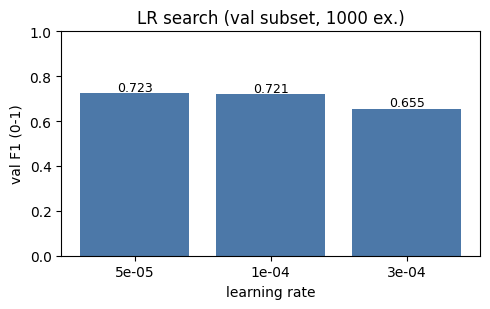

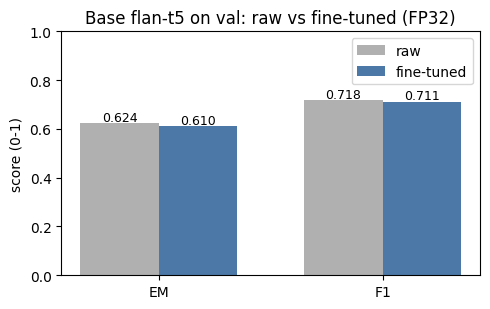

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# baseline (raw, fp32) on the SAME val split -> clean before/after on val
raw_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_BASE).to(device)
raw_row, _ = evaluate_model(
    raw_model, tokenizer, ds["val"],
    model_name="flan-t5-base", state="raw", precision_mode="fp32",
)
del raw_model
torch.cuda.empty_cache()

print("raw val:", raw_row)
print("ft  val:", row)
print("EM-F1 gap  raw:", round(raw_row["f1"] - raw_row["exact_match"], 3),
      "| fine-tuned:", round(row["f1"] - row["exact_match"], 3))

os.makedirs("results", exist_ok=True)

# Fig 1 - LR search
lrs = [f"{r['lr']:.0e}" for r in search_results]
f1s = [r["f1"] for r in search_results]
plt.figure(figsize=(5, 3.2))
plt.bar(lrs, f1s, color="#4C78A8")
for i, v in enumerate(f1s):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.ylim(0, 1)
plt.ylabel("val F1 (0-1)")
plt.xlabel("learning rate")
plt.title(f"LR search (val subset, {SEARCH_VAL_N} ex.)")
plt.tight_layout()
plt.savefig("results/finetune_lr_search.png", dpi=150)
plt.show()

# Fig 2 - raw vs fine-tuned on val (EM & F1)
labels = ["EM", "F1"]
raw_vals = [raw_row["exact_match"], raw_row["f1"]]
ft_vals  = [row["exact_match"], row["f1"]]
x = np.arange(len(labels)); w = 0.35
plt.figure(figsize=(5, 3.2))
plt.bar(x - w/2, raw_vals, w, label="raw",        color="#B0B0B0")
plt.bar(x + w/2, ft_vals,  w, label="fine-tuned", color="#4C78A8")
for i, v in enumerate(raw_vals):
    plt.text(x[i] - w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(ft_vals):
    plt.text(x[i] + w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("score (0-1)")
plt.title("Base flan-t5 on val: raw vs fine-tuned (FP32)")
plt.legend()
plt.tight_layout()
plt.savefig("results/val_raw_vs_ft.png", dpi=150)
plt.show()

## Publishing the checkpoint

The fine-tuned checkpoint is published to the Hugging Face Hub (the `models/` folder is gitignored). Authentication requires a write token.

In [12]:
from huggingface_hub import notebook_login
notebook_login()   # paste a HF token with WRITE access

In [14]:
HF_USERNAME = "Smambu"
REPO_ID = f"{HF_USERNAME}/flan-t5-base-adversarialqa-ft"

ft_model.push_to_hub(REPO_ID)
tokenizer.push_to_hub(REPO_ID)

print("Published:", REPO_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...taxt42a/model.safetensors:   0%|          |  553kB /  990MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Published: Smambu/flan-t5-base-adversarialqa-ft
